# Scaling comparison for different MPF bounds

This notebook studies how the choice of error bound for the multiproduct formula (MPF) changes resource scaling. In particular, it compares the segment counts and resulting T-count and CNOT-count obtained from the historical proxy and rigorous bounds as the system size and target precision vary.

The analytical and dense exact-evolution checks below validate the bounds used in this scaling comparison; they are supporting checks rather than the main purpose of the notebook.

The implemented bound is

$$B_2=\sum_j |a_j|/k_j^2,\qquad \delta_r=W_2|t/r|^3B_2,$$

$$E_r=r\delta_r(1+\delta_r)^{r-1}.$$

The absolute values deliberately discard MPF cancellation. All direct claims below have `scope="ideal-mpf"`.

In [1]:
import json
import math

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from qiskit.quantum_info import Operator
from scipy.linalg import expm

from hamiltonian_resources import (
    BenchmarkConfig,
    MultiproductMethod,
    PauliHamiltonian,
    TimeScaling,
    build_trotter_circuit,
    plot_benchmark,
    run_benchmark,
    transverse_field_ising,
)
from hamiltonian_resources.multiproduct import (
    _w2_triangle_ideal_mpf_bound,
    estimate_mpf_error,
    multiproduct_coefficients,
    optimal_mpf_exponents,
    select_mpf_segments,
)
from hamiltonian_resources.trotter import estimate_suzuki_error, suzuki_commutator_bounds

W2_METHOD = "childs2021-w2-triangle-ideal-rigorous"
pd.set_option("display.max_colwidth", 100)

/Users/xisn/Documents/001_hamiltonian_simulation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Resource scaling under different MPF bounds

The following benchmark highlights the scaling differences caused by the choice of MPF error bound. Each bound can select a different number of segments for the same target error, which in turn changes the T-count and CNOT-count. The evolution time is fixed at $t=0.2$ so that the two sweeps isolate the effects of system size and requested precision. The system-size sweep fixes $\epsilon=10^{-3}$; the precision sweep fixes $n=6$. Both axes and resource counts are logarithmic.

Edit `scaling_system_sizes`, `scaling_target_errors`, or `scaling_methods` to explore a different range. Mizuta is included for completeness and can be removed for a faster exploratory run.

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:550: UserWarning: The figure layout has changed to tight
  figure.tight_layout()
/var/folders/nb/dn40bb4d2pncg1qrxsqcrtkr0000gn/T/ipykernel_96749/75701802.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


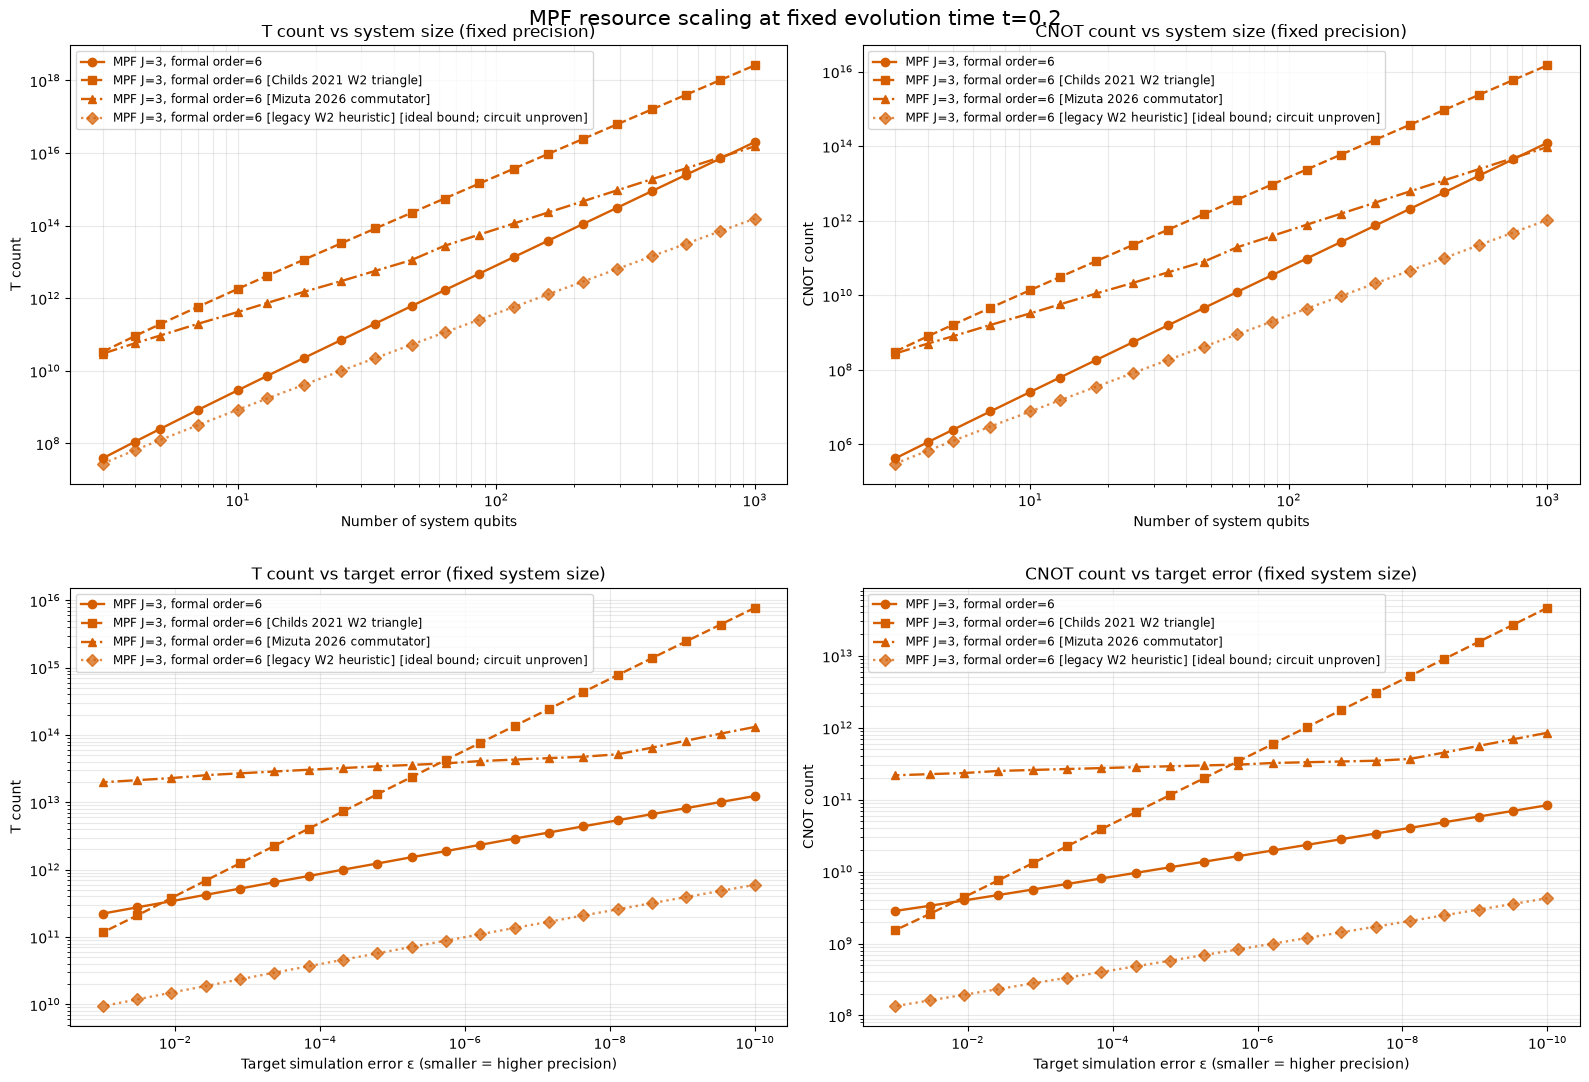

In [17]:
scaling_system_sizes = np.geomspace(3, 1000, num=20, dtype=np.int_)
scaling_target_errors = np.logspace(-1, -10, 20)
scaling_methods = [
    MultiproductMethod(3, error_method="low2019-l1-ideal-rigorous"),
    MultiproductMethod(3, error_method=W2_METHOD),
    MultiproductMethod(3, error_method="mizuta2026-commutator-ideal-rigorous"),
    MultiproductMethod(3, error_method="legacy-w2-proxy"),
]
scaling_config = BenchmarkConfig(
    system_sizes=scaling_system_sizes,
    target_errors=scaling_target_errors,
    time=TimeScaling("proportional", 1.0),
    fixed_system_size=100,
    fixed_target_error=1e-9,
    methods=scaling_methods,
)
scaling_data = run_benchmark(scaling_config)

figure, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
for column, metric in enumerate(("t_count", "cnot_count")):
    plot_benchmark(
        scaling_data,
        sweep="system-size",
        metric=metric,
        series_by="method_label",
        ax=axes[0, column],
    )
    plot_benchmark(
        scaling_data,
        sweep="target-error",
        metric=metric,
        series_by="method_label",
        ax=axes[1, column],
    )
axes[0, 0].set_title("T count vs system size (fixed precision)")
axes[0, 1].set_title("CNOT count vs system size (fixed precision)")
axes[1, 0].set_title("T count vs target error (fixed system size)")
axes[1, 1].set_title("CNOT count vs target error (fixed system size)")
figure.suptitle("MPF resource scaling at fixed evolution time t=0.2", fontsize=15)
figure.show()

### Underlying resource table

Use this table to inspect exact segment and gate counts behind the plots.

In [3]:
scaling_data[[
    "sweep",
    "system_qubits",
    "target_error",
    "method_label",
    "bound_method",
    "segment_count",
    "t_count",
    "cnot_count",
]].sort_values(["sweep", "method_label", "system_qubits", "target_error"])

,sweep,system_qubits,target_error,method_label,bound_method,segment_count,t_count,cnot_count
0,system-size,2,0.001,"MPF J=3, formal order=6",low2019-l1-ideal-rigorous,2,36496,960
4,system-size,4,0.001,"MPF J=3, formal order=6",low2019-l1-ideal-rigorous,4,186224,3920
8,system-size,6,0.001,"MPF J=3, formal order=6",low2019-l1-ideal-rigorous,7,537572,10381
12,system-size,8,0.001,"MPF J=3, formal order=6",low2019-l1-ideal-rigorous,10,1084640,19864
1,system-size,2,0.001,"MPF J=3, formal order=6 [Childs 2021 W2 triangle]",childs2021-w2-triangle-ideal-rigorous,6,117048,2880
5,system-size,4,0.001,"MPF J=3, formal order=6 [Childs 2021 W2 triangle]",childs2021-w2-triangle-ideal-rigorous,10,489080,9800
9,system-size,6,0.001,"MPF J=3, formal order=6 [Childs 2021 W2 triangle]",childs2021-w2-triangle-ideal-rigorous,12,943728,17795
13,system-size,8,0.001,"MPF J=3, formal order=6 [Childs 2021 W2 triangle]",childs2021-w2-triangle-ideal-rigorous,14,1536136,27810
2,system-size,2,0.001,"MPF J=3, formal order=6 [Mizuta 2026 commutator]",mizuta2026-commutator-ideal-rigorous,10798,300443552,5183040
6,system-size,4,0.001,"MPF J=3, formal order=6 [Mizuta 2026 commutator]",mizuta2026-commutator-ideal-rigorous,14141,957685084,13858180


## 1. Schedule coefficients, cancellation, and B2

The signed $q=1$ sum is approximately zero, while $B_2$ remains positive because it uses absolute values.

In [4]:
schedule_rows = []
for J in (2, 3, 5):
    coefficients = multiproduct_coefficients(J)
    exponents = optimal_mpf_exponents(J)
    signed_q1 = math.fsum(
        float(a) / k**2 for a, k in zip(coefficients, exponents, strict=True)
    )
    b2 = math.fsum(
        abs(float(a)) / k**2 for a, k in zip(coefficients, exponents, strict=True)
    )
    schedule_rows.append(
        {
            "J": J,
            "exponents": exponents,
            "coefficient_l1": float(np.sum(np.abs(coefficients))),
            "signed_q1_sum": signed_q1,
            "B2": b2,
        }
    )
schedule_table = pd.DataFrame(schedule_rows)
assert np.all(np.abs(schedule_table["signed_q1_sum"]) < 1e-14)
assert np.all(schedule_table["B2"] > 0)
schedule_table

,J,exponents,coefficient_l1,signed_q1_sum,B2
0,2,"(1, 2)",1.666667,0.000000e+00,0.666667
1,3,"(1, 2, 4)",1.888889,-6.938894e-18,0.222222
2,5,"(1, 2, 3, 5, 12)",1.825738,-3.117081e-19,0.035468


## 2. Direct formula and minimal segment selection

In [5]:
hamiltonian = transverse_field_ising(2, coupling=1.0, field=3.0, periodic=False)
time = 2.0
target_error = 9e-4
J = 3

selected = select_mpf_segments(
    hamiltonian, time, target_error, J, method=W2_METHOD
)
previous = estimate_mpf_error(
    hamiltonian, time, selected.segments - 1, J, method=W2_METHOD
)
components = dict(selected.bound_components)
delta = components["w2"] * abs(time / selected.segments) ** 3 * components["b2"]
reconstructed = selected.segments * delta * (1 + delta) ** (selected.segments - 1)

assert selected.segments == 161
assert selected.error <= target_error < previous.error
assert math.isclose(delta, components["local_step_error"], rel_tol=1e-15)
assert math.isclose(reconstructed, selected.error, rel_tol=1e-12)
pd.Series(
    {
        "segments": selected.segments,
        "selected_error": selected.error,
        "previous_error": previous.error,
        **components,
    },
    name="W2 triangle diagnostics",
)

segments                    161.000000
selected_error                0.000892
previous_error                0.000904
w2                           13.000000
b2                            0.222222
local_step_size               0.012422
local_step_error              0.000006
repeated_ideal_mpf_error      0.000892
Name: W2 triangle diagnostics, dtype: float64

## 3. Dense exact-evolution validation

For small systems, construct the ideal MPF matrix directly and verify both the local and repeated operator-norm bounds.

In [6]:
def ideal_mpf_step(h, step_time, J):
    return sum(
        coefficient
        * Operator(
            build_trotter_circuit(
                h, step_time, reps=exponent, order=2, partition="individual"
            )
        ).data
        for coefficient, exponent in zip(
            multiproduct_coefficients(J),
            optimal_mpf_exponents(J),
            strict=True,
        )
    )


tiny = PauliHamiltonian.from_terms(
    2, [("XI", 0.31), ("YZ", -0.47), ("ZZ", 0.23), ("IX", -0.19)]
)
validation_rows = []
for J in (2, 3, 5):
    for total_time, segments in ((0.08, 1), (0.24, 3)):
        estimate = estimate_mpf_error(
            tiny, total_time, segments, J, method=W2_METHOD
        )
        step_time = total_time / segments
        step = ideal_mpf_step(tiny, step_time, J)
        local_exact = expm(-1j * step_time * tiny.matrix())
        total_exact = expm(-1j * total_time * tiny.matrix())
        local_error = float(np.linalg.norm(step - local_exact, ord=2))
        repeated_error = float(
            np.linalg.norm(np.linalg.matrix_power(step, segments) - total_exact, ord=2)
        )
        assert local_error <= estimate.local_error * (1 + 1e-12) + 1e-12
        assert repeated_error <= estimate.error * (1 + 1e-12) + 1e-12
        validation_rows.append(
            {
                "J": J,
                "time": total_time,
                "segments": segments,
                "exact_local": local_error,
                "local_bound": estimate.local_error,
                "exact_repeated": repeated_error,
                "repeated_bound": estimate.error,
            }
        )
pd.DataFrame(validation_rows)

,J,time,segments,exact_local,local_bound,exact_repeated,repeated_bound
0,2,0.08,1,1.467041e-09,0.000030,1.467041e-09,0.000030
1,2,0.24,3,1.467041e-09,0.000030,4.397194e-09,0.000089
2,3,0.08,1,3.846203e-14,0.000010,3.846203e-14,0.000010
3,3,0.24,3,3.846203e-14,0.000010,1.151679e-13,0.000030
4,5,0.08,1,4.194163e-15,0.000002,4.194163e-15,0.000002
5,5,0.24,3,4.194163e-15,0.000002,1.262950e-14,0.000005


## 4. Four-way estimator comparison

This representative case shows the intended tradeoff. The historical proxy is optimistic but nonrigorous; W2 triangle is rigorous and commutation-sensitive but discards high-order cancellation; Mizuta is rigorous but its finite-size time conditions can dominate.

In [7]:
comparison_J = 3
comparison_methods = (
    "legacy-w2-proxy",
    "low2019-l1-ideal-rigorous",
    W2_METHOD,
    "mizuta2026-commutator-ideal-rigorous",
)
comparison_rows = []
for method in comparison_methods:
    estimate = select_mpf_segments(
        hamiltonian, time, target_error, comparison_J, method=method
    )
    comparison_rows.append(
        {
            "method": method,
            "segments": estimate.segments,
            "bound_at_selected_r": estimate.error,
            "rigorous": estimate.rigorous,
            "scope": estimate.scope,
        }
    )
comparison_table = pd.DataFrame(comparison_rows)
assert comparison_table.set_index("method")["segments"].to_dict() == {
    "legacy-w2-proxy": 20,
    "low2019-l1-ideal-rigorous": 24,
    W2_METHOD: 161,
    "mizuta2026-commutator-ideal-rigorous": 123_406,
}
comparison_table

,method,segments,bound_at_selected_r,rigorous,scope
0,legacy-w2-proxy,20,0.000795,False,ideal-mpf
1,low2019-l1-ideal-rigorous,24,0.000741,True,ideal-mpf
2,childs2021-w2-triangle-ideal-rigorous,161,0.000892,True,ideal-mpf
3,mizuta2026-commutator-ideal-rigorous,123406,0.000370,True,ideal-mpf


## 5. Best-rigorous policy and candidate provenance

In [8]:
identity_heavy = PauliHamiltonian.from_terms(
    1, [("I", 1000.0), ("X", 0.1), ("Z", 0.1)]
)
best = select_mpf_segments(
    identity_heavy, 0.01, 1e-3, 2, method="best-rigorous-ideal"
)
candidate_table = pd.DataFrame(candidate.as_dict() for candidate in best.bound_candidates)
assert best.method == W2_METHOD
assert candidate_table["method"].tolist() == [
    "low2019-l1-ideal-rigorous",
    W2_METHOD,
    "mizuta2026-commutator-ideal-rigorous",
]
print("selected:", best.method, "segments:", best.segments)
candidate_table

selected: childs2021-w2-triangle-ideal-rigorous segments: 1


,method,segments,error,rigorous,fallback_reason,max_exact_nested_commutator_order
0,low2019-l1-ideal-rigorous,44,9.320502e-04,True,None,0
1,childs2021-w2-triangle-ideal-rigorous,1,3.333333e-10,True,None,3
2,mizuta2026-commutator-ideal-rigorous,8,7.377813e-04,True,None,12


## 6. Benchmark-row provenance

The direct W2 claim remains scoped to the ideal MPF. Any amplified or reused-ancilla claim is derived and serialized separately by the planning layer.

In [9]:
benchmark_row = run_benchmark(
    BenchmarkConfig(
        system_sizes=[2],
        time=TimeScaling("fixed", 0.2),
        methods=[MultiproductMethod(3, error_method=W2_METHOD)],
    ),
    sweeps="system-size",
).iloc[0]
serialized_components = json.loads(benchmark_row["bound_components_json"])
assert benchmark_row["bound_method"] == W2_METHOD
assert bool(benchmark_row["bound_rigorous"])
assert benchmark_row["bound_scope"] == "ideal-mpf"
assert set(serialized_components) == {
    "w2", "b2", "local_step_size", "local_step_error", "repeated_ideal_mpf_error"
}
benchmark_row[[
    "method_id",
    "bound_method",
    "bound_rigorous",
    "bound_scope",
    "circuit_bound_scope",
    "circuit_bound_rigorous",
    "bound_components_json",
]]

method_id                                                                        mpf-m3-childs2021-w2-triangle-ideal-rigorous
bound_method                                                                            childs2021-w2-triangle-ideal-rigorous
bound_rigorous                                                                                                           True
bound_scope                                                                                                         ideal-mpf
circuit_bound_scope                                                                        repeated-shared-ancilla-good-block
circuit_bound_rigorous                                                                                                   True
bound_components_json     {"b2":0.2222222222222222,"local_step_error":0.00010699588477366247,"local_step_size":0.033333333...
Name: 0, dtype: object

## 7. Commuting and J=1 sanity checks

In [10]:
commuting = PauliHamiltonian.from_terms(
    2, [("ZI", 0.7), ("IZ", -0.2), ("ZZ", 0.4)]
)
commuting_estimate = select_mpf_segments(
    commuting, 5.0, 1e-12, 3, method=W2_METHOD
)
assert commuting_estimate.segments == 1
assert commuting_estimate.error == 0.0

single_branch_h = transverse_field_ising(3, field=0.7)
single_time = 0.4
single_segments = 7
_, w2 = suzuki_commutator_bounds(single_branch_h)
single_repeated, single_prefactor, single_local, single_b2 = (
    _w2_triangle_ideal_mpf_bound(
        w2, single_time, single_segments, (1.0,), (1,)
    )
)
ordinary_trotter = estimate_suzuki_error(
    single_branch_h,
    single_time,
    reps=single_segments,
    order=2,
    partition="individual",
)
assert single_b2 == 1.0
assert single_prefactor == w2
assert math.isclose(single_local, w2 * abs(single_time / single_segments) ** 3)
assert math.isclose(single_repeated, ordinary_trotter.error, rel_tol=1e-12)
pd.Series(
    {
        "commuting_W2": dict(commuting_estimate.bound_components)["w2"],
        "commuting_segments": commuting_estimate.segments,
        "J1_B2": single_b2,
        "J1_local_bound": single_local,
        "J1_repeated_bound": single_repeated,
        "ordinary_trotter_bound": ordinary_trotter.error,
    },
    name="sanity checks",
)

commuting_W2              0.000000
commuting_segments        1.000000
J1_B2                     1.000000
J1_local_bound            0.000374
J1_repeated_bound         0.002621
ordinary_trotter_bound    0.002621
Name: sanity checks, dtype: float64

## Conclusion

If every assertion above passes, the new estimator reproduces its analytical formulas, upper-bounds the tested exact ideal-MPF errors, retains auditable provenance, selects minimal segments, handles commuting Hamiltonians, and reduces to ordinary second-order Trotter for the single-branch helper case. No proof-level MPF cancellation was assumed.